In [ ]:
# Program 1: Regression Analysis with Housing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("REGRESSION ANALYSIS: Predicting Continuous Values")
print("=" * 70)

# Load California Housing dataset
print("\n📊 Loading California Housing Dataset...")
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target * 100000  # Convert to actual dollar values

print(f"Dataset Shape: {df.shape}")
print(f"Features: {list(df.columns)}")

REGRESSION ANALYSIS: Predicting Continuous Values

📊 Loading California Housing Dataset...
Dataset Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [3]:
# 1. COMPREHENSIVE EDA FOR REGRESSION
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS - REGRESSION")
print("="*50)

# Basic dataset info
print("\n📈 Dataset Overview:")
print(df.info())
print(f"\nMissing Values:\n{df.isnull().sum()}")



EXPLORATORY DATA ANALYSIS - REGRESSION

📈 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [4]:
# Statistical summary
print("\n📊 Statistical Summary:")
print(df.describe())


📊 Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    MedHouseVal  
count  20640.000000  20640.000000  20640.000000   20640.000000  
mean       3.070655     35.631861   -119.569704  206855.816909  
std       10.386050      2.135952      2.003532  115395.615874  
min 

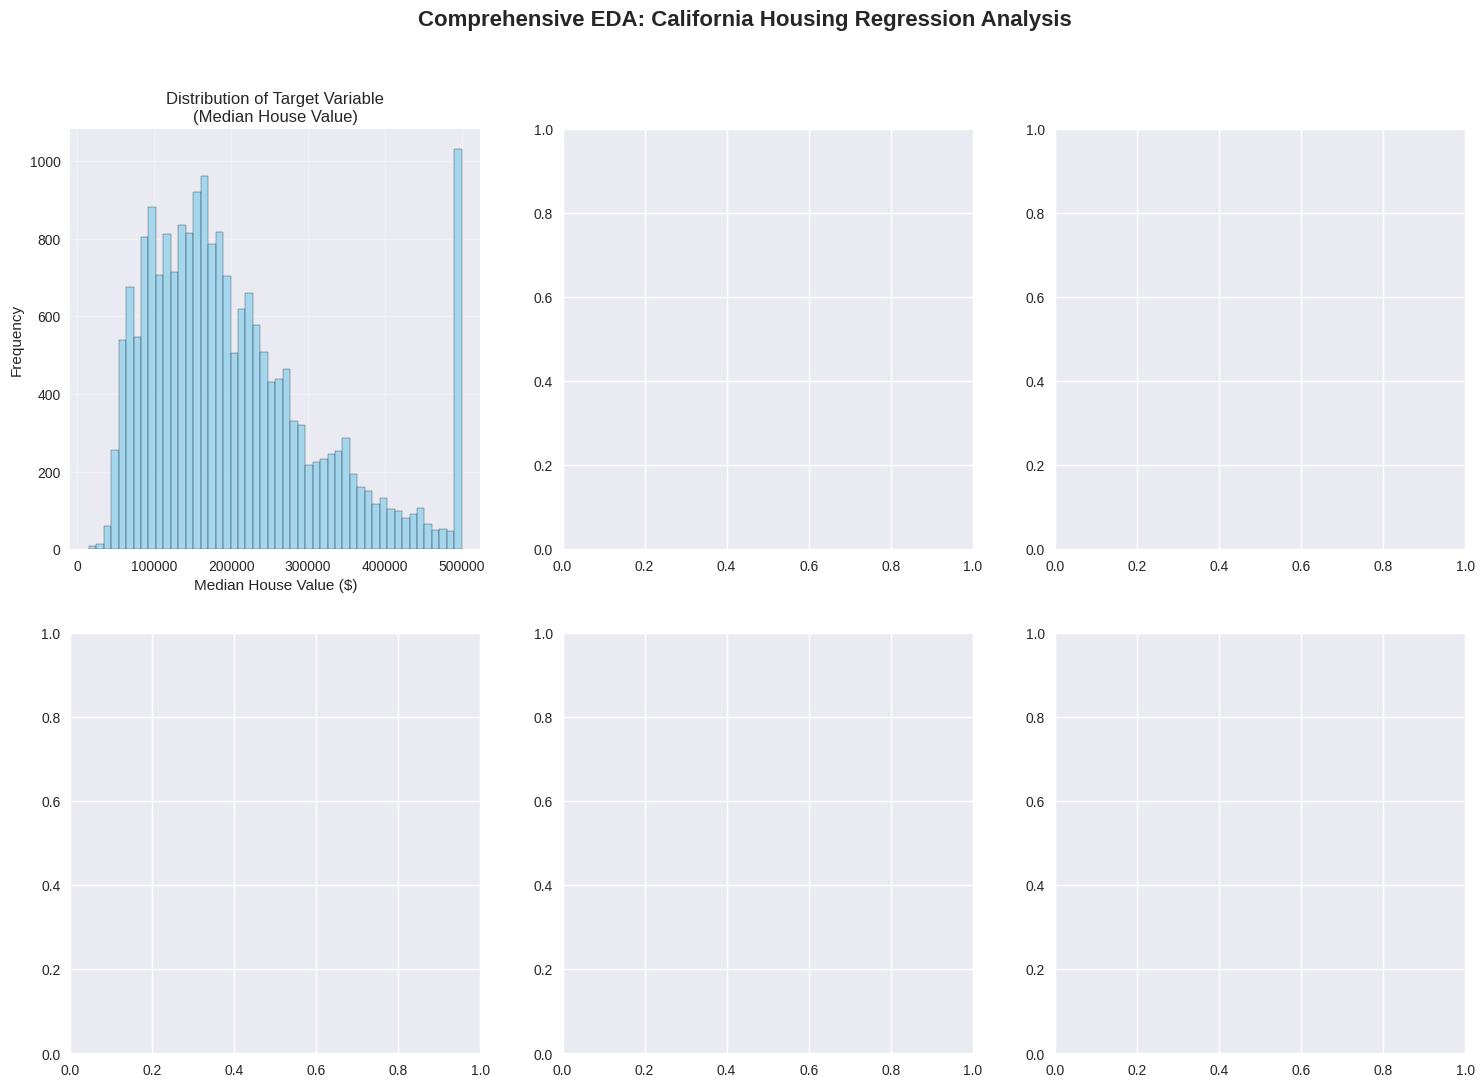

In [5]:
# Create subplots for EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comprehensive EDA: California Housing Regression Analysis', fontsize=16, fontweight='bold')

# Distribution of target variable
axes[0,0].hist(df['MedHouseVal'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Median House Value ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Target Variable\n(Median House Value)')
axes[0,0].grid(True, alpha=0.3)

In [6]:
# Correlation heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,1])
axes[0,1].set_title('Feature Correlation Heatmap')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

In [7]:
# Price vs MedInc (most correlated feature)
axes[0,2].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5, color='green')
axes[0,2].set_xlabel('Median Income')
axes[0,2].set_ylabel('Median House Value ($)')
axes[0,2].set_title('House Value vs Median Income')
axes[0,2].grid(True, alpha=0.3)

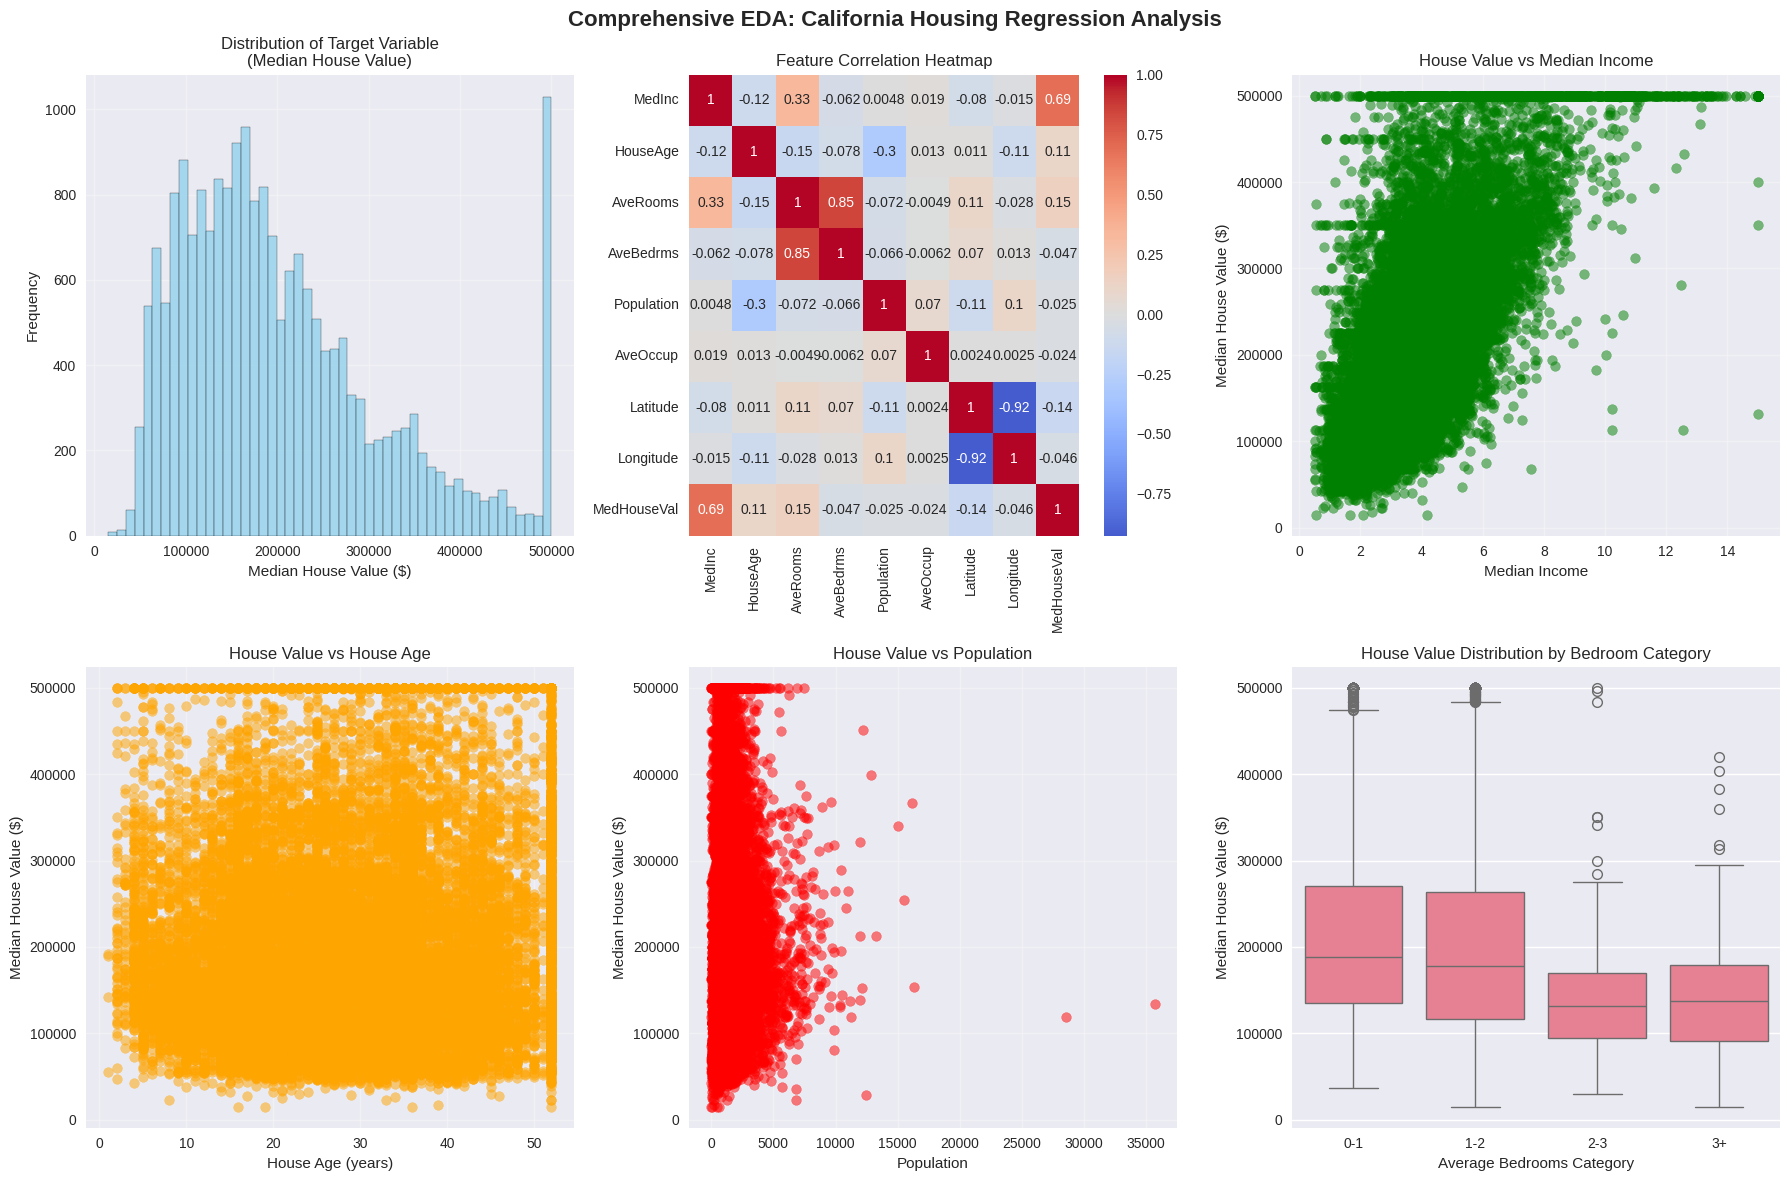

In [8]:
# Create subplots for EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comprehensive EDA: California Housing Regression Analysis', fontsize=16, fontweight='bold')

# Distribution of target variable
axes[0,0].hist(df['MedHouseVal'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Median House Value ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Target Variable\n(Median House Value)')
axes[0,0].grid(True, alpha=0.3)

# Correlation heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,1])
axes[0,1].set_title('Feature Correlation Heatmap')

# Price vs MedInc (most correlated feature)
axes[0,2].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5, color='green')
axes[0,2].set_xlabel('Median Income')
axes[0,2].set_ylabel('Median House Value ($)')
axes[0,2].set_title('House Value vs Median Income')
axes[0,2].grid(True, alpha=0.3)

# Price vs HouseAge
axes[1,0].scatter(df['HouseAge'], df['MedHouseVal'], alpha=0.5, color='orange')
axes[1,0].set_xlabel('House Age (years)')
axes[1,0].set_ylabel('Median House Value ($)')
axes[1,0].set_title('House Value vs House Age')
axes[1,0].grid(True, alpha=0.3)

# Price vs Population
axes[1,1].scatter(df['Population'], df['MedHouseVal'], alpha=0.5, color='red')
axes[1,1].set_xlabel('Population')
axes[1,1].set_ylabel('Median House Value ($)')
axes[1,1].set_title('House Value vs Population')
axes[1,1].grid(True, alpha=0.3)

# Boxplot of house values by number of bedrooms (discretized)
df['Bedroom_Cat'] = pd.cut(df['AveBedrms'], bins=[0, 1, 2, 3, 10], labels=['0-1', '1-2', '2-3', '3+'])
sns.boxplot(data=df, x='Bedroom_Cat', y='MedHouseVal', ax=axes[1,2])
axes[1,2].set_title('House Value Distribution by Bedroom Category')
axes[1,2].set_xlabel('Average Bedrooms Category')
axes[1,2].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()

In [11]:
# 2. FEATURE ENGINEERING AND MODEL TRAINING
print("\n" + "="*50)
print("REGRESSION MODEL TRAINING")
print("="*50)

# Prepare features and target
X = df.drop(['MedHouseVal', 'Bedroom_Cat'], axis=1)
y = df['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train Linear Regression model
print("\n🤖 Training Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


REGRESSION MODEL TRAINING
Training set size: 16512
Test set size: 4128

🤖 Training Linear Regression Model...


LinearRegression()

In [12]:
# Make predictions
y_pred = lr_model.predict(X_test)

In [13]:
# 3. MODEL EVALUATION AND VISUALIZATION
print("\n" + "="*50)
print("REGRESSION MODEL EVALUATION")
print("="*50)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Regression Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


REGRESSION MODEL EVALUATION
📊 Regression Metrics:
Mean Absolute Error (MAE): $53,320.01
Root Mean Squared Error (RMSE): $74,558.14
R² Score: 0.5758



🔍 Feature Importance:
      feature    importance
3   AveBedrms  78314.490679
0      MedInc  44867.490967
7   Longitude  43370.806496
6    Latitude  41979.248659
2    AveRooms  12332.334283
1    HouseAge    972.425752
5    AveOccup    352.631849
4  Population      0.202962


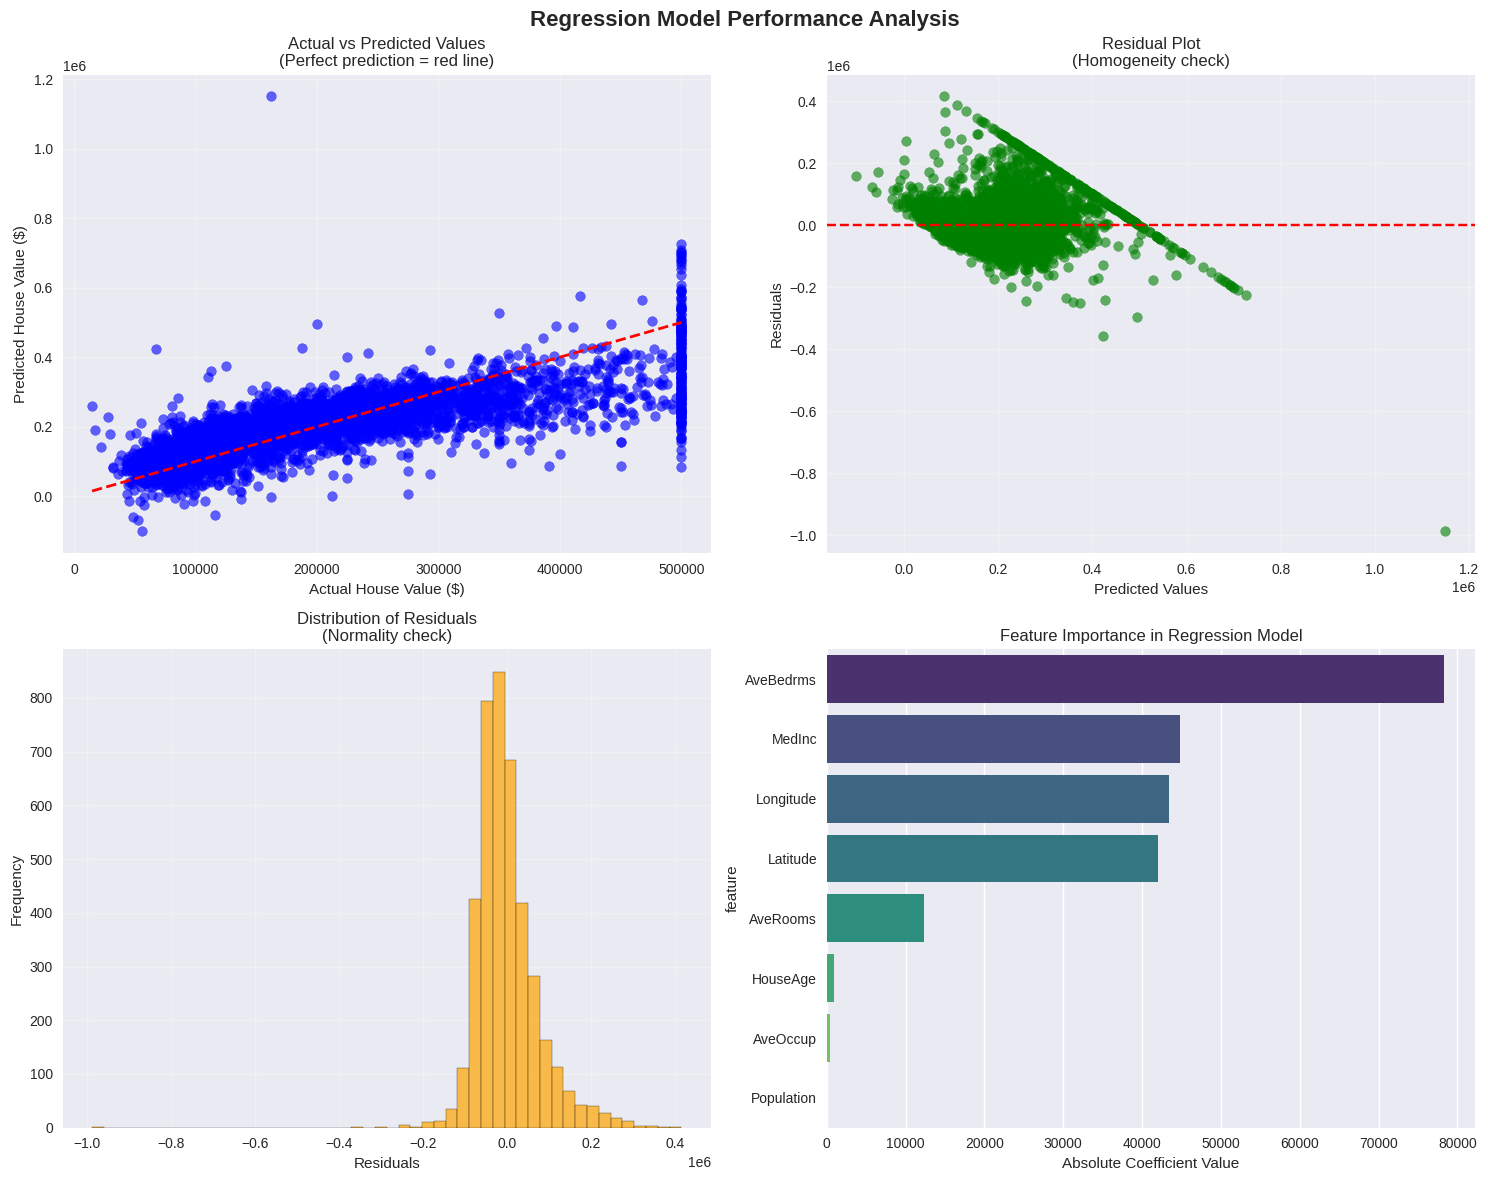


REGRESSION CONCEPTS EXPLANATION

📈 REGRESSION ANALYSIS KEY POINTS:

1. **Objective**: Predict continuous numerical values
   - Example: House prices, temperature, stock prices

2. **Target Variable**: Continuous (MedHouseVal)
   - Range: $10,000 - $500,000

3. **Evaluation Metrics**:
   - MAE (Mean Absolute Error): Average absolute difference
   - RMSE (Root Mean Squared Error): Penalizes larger errors more
   - R² Score: Proportion of variance explained (0-1)

4. **Model Interpretation**:
   - Coefficients show feature impact on target
   - Positive coefficient = positive correlation
   - Negative coefficient = negative correlation

5. **Residual Analysis**:
   - Residuals should be randomly distributed
   - No patterns in residual plot
   - Approximately normal distribution


🎯 Sample Predictions vs Actual Values:
  Actual Predicted     Error
 $47,700   $71,912  $-24,212
 $45,800  $176,402 $-130,602
$500,001  $270,966  $229,035
$218,600  $283,893  $-65,293
$278,000  $260,466   $17,5

In [14]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(lr_model.coef_)
}).sort_values('importance', ascending=False)

print(f"\n🔍 Feature Importance:")
print(feature_importance)

# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Regression Model Performance Analysis', fontsize=16, fontweight='bold')

# Actual vs Predicted values
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='blue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual House Value ($)')
axes[0,0].set_ylabel('Predicted House Value ($)')
axes[0,0].set_title('Actual vs Predicted Values\n(Perfect prediction = red line)')
axes[0,0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.6, color='green')
axes[0,1].axhline(y=0, color='red', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residual Plot\n(Homogeneity check)')
axes[0,1].grid(True, alpha=0.3)

# Distribution of residuals
axes[1,0].hist(residuals, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Residuals\n(Normality check)')
axes[1,0].grid(True, alpha=0.3)

# Feature importance bar plot
sns.barplot(data=feature_importance, x='importance', y='feature', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Feature Importance in Regression Model')
axes[1,1].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()
plt.show()

# 4. REGRESSION CONCEPTS EXPLANATION
print("\n" + "="*70)
print("REGRESSION CONCEPTS EXPLANATION")
print("="*70)
print("""
📈 REGRESSION ANALYSIS KEY POINTS:

1. **Objective**: Predict continuous numerical values
   - Example: House prices, temperature, stock prices

2. **Target Variable**: Continuous (MedHouseVal)
   - Range: $10,000 - $500,000

3. **Evaluation Metrics**:
   - MAE (Mean Absolute Error): Average absolute difference
   - RMSE (Root Mean Squared Error): Penalizes larger errors more
   - R² Score: Proportion of variance explained (0-1)

4. **Model Interpretation**:
   - Coefficients show feature impact on target
   - Positive coefficient = positive correlation
   - Negative coefficient = negative correlation

5. **Residual Analysis**:
   - Residuals should be randomly distributed
   - No patterns in residual plot
   - Approximately normal distribution
""")

# Sample predictions
print("\n🎯 Sample Predictions vs Actual Values:")
sample_results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Error': residuals[:10]
})
sample_results['Actual'] = sample_results['Actual'].apply(lambda x: f"${x:,.0f}")
sample_results['Predicted'] = sample_results['Predicted'].apply(lambda x: f"${x:,.0f}")
sample_results['Error'] = sample_results['Error'].apply(lambda x: f"${x:,.0f}")
print(sample_results.to_string(index=False))